In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


In [2]:
RUN_DIR_svd = Path("state_spectrum_sweep/experiments/mamba_ssm_low_rank_20260416_075255")
RUN_DIR_q = Path("state_spectrum_sweep/experiments/mamba_ssm_quant_20260416_073104")

assert RUN_DIR_svd.exists(), f"Run directory not found: {RUN_DIR_svd}"
assert RUN_DIR_q.exists(), f"Run directory not found: {RUN_DIR_q}"

RUN_DIR_svd, RUN_DIR_q


(PosixPath('state_spectrum_sweep/experiments/mamba_ssm_low_rank_20260416_075255'),
 PosixPath('state_spectrum_sweep/experiments/mamba_ssm_quant_20260416_073104'))

In [3]:
def load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def load_tensor(path: Path):
    return torch.load(path, map_location="cpu")

def prompt_ids(run_dir: Path):
    return sorted({p.name.split("_meta.json")[0] for p in run_dir.glob("prompt_*_meta.json")})

def load_prompt_artifacts(run_dir: Path, prompt_id: str):
    meta_path = run_dir / f"{prompt_id}_meta.json"
    text_path = run_dir / f"{prompt_id}_prompt_response.txt"

    artifacts = {
        "prompt_id": prompt_id,
        "meta": load_json(meta_path) if meta_path.exists() else None,
        "response_text": text_path.read_text(encoding="utf-8") if text_path.exists() else None,
    }

    for metric_name in ["kl", "mse", "rel_frob", "cosine_similarity", "retained_energy"]:
        tensor_path = run_dir / f"{prompt_id}_{metric_name}.pt"
        artifacts[metric_name] = load_tensor(tensor_path) if tensor_path.exists() else None

    return artifacts

def load_run(run_dir: Path):
    ids = prompt_ids(run_dir)
    return [load_prompt_artifacts(run_dir, prompt_id) for prompt_id in ids]

all_prompt_ids_svd = prompt_ids(RUN_DIR_svd)
all_prompt_ids_q = prompt_ids(RUN_DIR_q)

all_prompt_ids_svd, all_prompt_ids_q[:5]


(['prompt_01',
  'prompt_02',
  'prompt_03',
  'prompt_04',
  'prompt_05',
  'prompt_06',
  'prompt_07',
  'prompt_08',
  'prompt_09',
  'prompt_10',
  'prompt_11',
  'prompt_12',
  'prompt_13',
  'prompt_14',
  'prompt_15',
  'prompt_16',
  'prompt_17',
  'prompt_18',
  'prompt_19',
  'prompt_20',
  'prompt_21',
  'prompt_22',
  'prompt_23',
  'prompt_24',
  'prompt_25',
  'prompt_26'],
 ['prompt_01', 'prompt_02', 'prompt_03', 'prompt_04', 'prompt_05'])

In [4]:
all_prompt_ids_q = prompt_ids(RUN_DIR_q)
all_prompt_ids_q

['prompt_01',
 'prompt_02',
 'prompt_03',
 'prompt_04',
 'prompt_05',
 'prompt_06',
 'prompt_07',
 'prompt_08',
 'prompt_09',
 'prompt_10',
 'prompt_11',
 'prompt_12',
 'prompt_13',
 'prompt_14',
 'prompt_15',
 'prompt_16',
 'prompt_17',
 'prompt_18',
 'prompt_19',
 'prompt_20',
 'prompt_21',
 'prompt_22',
 'prompt_23',
 'prompt_24',
 'prompt_25',
 'prompt_26',
 'prompt_27',
 'prompt_28',
 'prompt_29',
 'prompt_30']

In [5]:
records_svd = load_run(RUN_DIR_svd)
records_q = load_run(RUN_DIR_q)

len(records_svd), len(records_q)


(26, 30)

In [6]:
def index_by_prompt(records):
    return {r["prompt_id"]: r for r in records}

records_svd_by_id = index_by_prompt(records_svd)
records_q_by_id = index_by_prompt(records_q)

common_prompt_ids = sorted(set(records_svd_by_id) & set(records_q_by_id))
common_prompt_ids


['prompt_01',
 'prompt_02',
 'prompt_03',
 'prompt_04',
 'prompt_05',
 'prompt_06',
 'prompt_07',
 'prompt_08',
 'prompt_09',
 'prompt_10',
 'prompt_11',
 'prompt_12',
 'prompt_13',
 'prompt_14',
 'prompt_15',
 'prompt_16',
 'prompt_17',
 'prompt_18',
 'prompt_19',
 'prompt_20',
 'prompt_21',
 'prompt_22',
 'prompt_23',
 'prompt_24',
 'prompt_25',
 'prompt_26']

In [7]:
# Quick metadata check
meta_example_svd = records_svd_by_id[common_prompt_ids[0]]["meta"]
meta_example_q = records_q_by_id[common_prompt_ids[0]]["meta"]

meta_example_svd, meta_example_q

({'prompt_len': 7,
  'num_generated_tokens': 100,
  'num_metric_steps': 100,
  'stopped_reason': 'max_new_tokens',
  'prefill_seconds': 6.16000309001538,
  'average_transform_seconds': 10.264781501840334,
  'num_state_tensors': 128,
  'state_tensor_names': ['key_value_memory_dict.0.0',
   'key_value_memory_dict.0.1',
   'key_value_memory_dict.1.0',
   'key_value_memory_dict.1.1',
   'key_value_memory_dict.2.0',
   'key_value_memory_dict.2.1',
   'key_value_memory_dict.3.0',
   'key_value_memory_dict.3.1',
   'key_value_memory_dict.4.0',
   'key_value_memory_dict.4.1',
   'key_value_memory_dict.5.0',
   'key_value_memory_dict.5.1',
   'key_value_memory_dict.6.0',
   'key_value_memory_dict.6.1',
   'key_value_memory_dict.7.0',
   'key_value_memory_dict.7.1',
   'key_value_memory_dict.8.0',
   'key_value_memory_dict.8.1',
   'key_value_memory_dict.9.0',
   'key_value_memory_dict.9.1',
   'key_value_memory_dict.10.0',
   'key_value_memory_dict.10.1',
   'key_value_memory_dict.11.0',
   'ke

In [8]:
def summarize_step_layer_tensor(x: torch.Tensor):
    x = x.float().cpu()
    out = {
        "shape": tuple(x.shape),
        "mean": float(x.mean().item()),
        "std": float(x.std().item()) if x.numel() > 1 else 0.0,
        "min": float(x.min().item()),
        "max": float(x.max().item()),
    }

    if x.ndim >= 2:
        out["mean_over_layers_per_step"] = x.mean(dim=1)
        out["max_over_layers_per_step"] = x.max(dim=1).values
        out["mean_over_steps_per_layer"] = x.mean(dim=0)
        out["max_over_steps_per_layer"] = x.max(dim=0).values
    elif x.ndim == 1:
        out["per_step"] = x
    return out


In [9]:
def run_summary_dataframe(records, label):
    rows = []
    for rec in records:
        meta = rec["meta"] or {}
        row = {
            "run_type": label,
            "prompt_id": rec["prompt_id"],
            "experiment": meta.get("experiment"),
            "subset": meta.get("subset"),
            "prompt_len": meta.get("prompt_len"),
            "num_generated_tokens": meta.get("num_generated_tokens"),
            "num_metric_steps": meta.get("num_metric_steps"),
            "stopped_reason": meta.get("stopped_reason"),
            "prefill_seconds": meta.get("prefill_seconds"),
            "average_transform_seconds": meta.get("average_transform_seconds"),
            "num_state_tensors": meta.get("num_state_tensors"),
        }

        for metric_name in ["kl", "mse", "rel_frob", "cosine_similarity", "retained_energy"]:
            tensor = rec[metric_name]
            if tensor is None:
                continue
            stats = summarize_step_layer_tensor(tensor)
            row[f"{metric_name}_mean"] = stats["mean"]
            row[f"{metric_name}_std"] = stats["std"]
            row[f"{metric_name}_min"] = stats["min"]
            row[f"{metric_name}_max"] = stats["max"]

            if tensor.ndim == 1:
                row[f"{metric_name}_median"] = float(tensor.float().median().item())
                row[f"{metric_name}_p99"] = float(torch.quantile(tensor.float(), 0.99).item())

        rows.append(row)
    return pd.DataFrame(rows).sort_values(["run_type", "prompt_id"]).reset_index(drop=True)

df_svd = run_summary_dataframe(records_svd, "low_rank")
df_q = run_summary_dataframe(records_q, "quant")
df_all = pd.concat([df_svd, df_q], ignore_index=True)

df_all

,run_type,prompt_id,experiment,subset,prompt_len,num_generated_tokens,num_metric_steps,stopped_reason,prefill_seconds,average_transform_seconds,...,rel_frob_min,rel_frob_max,cosine_similarity_mean,cosine_similarity_std,cosine_similarity_min,cosine_similarity_max,retained_energy_mean,retained_energy_std,retained_energy_min,retained_energy_max
0,low_rank,prompt_01,low_rank,auto,7,100,100,max_new_tokens,6.160003,10.264782,...,0.000000,0.096191,0.999804,0.003829,0.992188,1.007812,0.999759,0.001006,0.992188,1.0
1,low_rank,prompt_02,low_rank,auto,8,100,100,max_new_tokens,0.041150,9.728872,...,0.000000,0.082520,0.999795,0.003773,0.992188,1.007812,0.999757,0.000987,0.992188,1.0
2,low_rank,prompt_03,low_rank,auto,9,100,100,max_new_tokens,0.037278,9.438831,...,0.000000,0.032959,0.999962,0.003871,0.992188,1.007812,1.000000,0.000000,1.000000,1.0
3,low_rank,prompt_04,low_rank,auto,12,100,100,max_new_tokens,0.123010,9.456752,...,0.000000,0.079102,0.999775,0.003770,0.992188,1.007812,0.999764,0.000942,0.992188,1.0
4,low_rank,prompt_05,low_rank,auto,14,100,100,max_new_tokens,0.036722,9.635067,...,0.000000,0.076172,0.999748,0.003747,0.992188,1.007812,0.999756,0.000945,0.996094,1.0
5,low_rank,prompt_06,low_rank,auto,14,100,100,max_new_tokens,0.037747,9.770674,...,0.000000,0.044189,0.999802,0.003764,0.992188,1.007812,1.000000,0.000000,1.000000,1.0
6,low_rank,prompt_07,low_rank,auto,14,100,100,max_new_tokens,0.142553,9.631500,...,0.000000,0.083984,0.999759,0.003710,0.992188,1.007812,0.999765,0.000982,0.992188,1.0
7,low_rank,prompt_08,low_rank,auto,10,100,100,max_new_tokens,0.042707,9.607469,...,0.000000,0.083984,0.999831,0.003798,0.992188,1.007812,0.999794,0.000923,0.992188,1.0
8,low_rank,prompt_09,low_rank,auto,12,100,100,max_new_tokens,0.037640,9.651883,...,0.000000,0.081543,0.999733,0.003790,0.988281,1.007812,0.999835,0.000797,0.992188,1.0
9,low_rank,prompt_10,low_rank,auto,10,100,100,max_new_tokens,0.093456,9.594185,...,0.000000,0.093750,0.999781,0.003776,0.992188,1.007812,0.999734,0.001051,0.992188,1.0


In [10]:
# Verify whether the retained energy tensor really contains only ones
x = records_svd_by_id["prompt_02"]["retained_energy"]
torch.unique(x)

tensor([0.9922, 0.9961, 1.0000])

In [11]:
# Join SVD and quant by prompt_id for direct comparison
paired = df_svd.merge(df_q, on="prompt_id", suffixes=("_svd", "_q"))
paired.head()


,run_type_svd,prompt_id,experiment_svd,subset_svd,prompt_len_svd,num_generated_tokens_svd,num_metric_steps_svd,stopped_reason_svd,prefill_seconds_svd,average_transform_seconds_svd,...,rel_frob_min_q,rel_frob_max_q,cosine_similarity_mean_q,cosine_similarity_std_q,cosine_similarity_min_q,cosine_similarity_max_q,retained_energy_mean_q,retained_energy_std_q,retained_energy_min_q,retained_energy_max_q
0,low_rank,prompt_01,low_rank,auto,7,100,100,max_new_tokens,6.160003,10.264782,...,0.010071,0.263672,0.994116,0.007873,0.964844,1.007812,0.988556,0.014827,0.929688,1.0
1,low_rank,prompt_02,low_rank,auto,8,100,100,max_new_tokens,0.041150,9.728872,...,0.009644,0.265625,0.994161,0.007756,0.960938,1.007812,0.988600,0.014632,0.929688,1.0
2,low_rank,prompt_03,low_rank,auto,9,100,100,max_new_tokens,0.037278,9.438831,...,0.010498,0.253906,0.993964,0.007638,0.964844,1.007812,0.988404,0.014524,0.937500,1.0
3,low_rank,prompt_04,low_rank,auto,12,100,100,max_new_tokens,0.123010,9.456752,...,0.009460,0.275391,0.994102,0.007761,0.957031,1.007812,0.988531,0.014749,0.921875,1.0
4,low_rank,prompt_05,low_rank,auto,14,100,100,max_new_tokens,0.036722,9.635067,...,0.010681,0.244141,0.994633,0.006964,0.964844,1.007812,0.989599,0.013114,0.941406,1.0


In [12]:
df_all.columns.tolist()

['run_type',
 'prompt_id',
 'experiment',
 'subset',
 'prompt_len',
 'num_generated_tokens',
 'num_metric_steps',
 'stopped_reason',
 'prefill_seconds',
 'average_transform_seconds',
 'num_state_tensors',
 'kl_mean',
 'kl_std',
 'kl_min',
 'kl_max',
 'kl_median',
 'kl_p99',
 'mse_mean',
 'mse_std',
 'mse_min',
 'mse_max',
 'rel_frob_mean',
 'rel_frob_std',
 'rel_frob_min',
 'rel_frob_max',
 'cosine_similarity_mean',
 'cosine_similarity_std',
 'cosine_similarity_min',
 'cosine_similarity_max',
 'retained_energy_mean',
 'retained_energy_std',
 'retained_energy_min',
 'retained_energy_max']

In [13]:
# 1. Single-prompt deep dive, mirroring the original notebook
PROMPT_ID = common_prompt_ids[1] if len(common_prompt_ids) > 1 else common_prompt_ids[0]

rec_svd = records_svd_by_id[PROMPT_ID]
rec_q = records_q_by_id[PROMPT_ID]

kl_svd = rec_svd["kl"].float().cpu()
mse_svd = rec_svd["mse"].float().cpu()
rf_svd = rec_svd["rel_frob"].float().cpu()
cos_svd = rec_svd["cosine_similarity"].float().cpu()
re_svd = rec_svd["retained_energy"].float().cpu()

kl_q = rec_q["kl"].float().cpu()
mse_q = rec_q["mse"].float().cpu()
rf_q = rec_q["rel_frob"].float().cpu()
cos_q = rec_q["cosine_similarity"].float().cpu()
re_q = rec_q["retained_energy"].float().cpu()

steps_svd = np.arange(len(kl_svd))
steps_q = np.arange(len(kl_q))

log_kl_svd = torch.log1p(kl_svd)
log_kl_q = torch.log1p(kl_q)

rf_mean_svd = rf_svd.mean(dim=1)
rf_max_svd = rf_svd.max(dim=1).values
rf_tail_svd = rf_svd[:, -4:].mean(dim=1)

mse_mean_svd = mse_svd.mean(dim=1)
mse_max_svd = mse_svd.max(dim=1).values

re_mean_svd = re_svd.mean(dim=1)
re_min_svd = re_svd.min(dim=1).values

cos_mean_svd = cos_svd.mean(dim=1)
cos_min_svd = cos_svd.min(dim=1).values

rf_mean_q = rf_q.mean(dim=1)
rf_max_q = rf_q.max(dim=1).values
rf_tail_q = rf_q[:, -4:].mean(dim=1)

mse_mean_q = mse_q.mean(dim=1)
mse_max_q = mse_q.max(dim=1).values

re_mean_q = re_q.mean(dim=1)
re_min_q = re_q.min(dim=1).values

cos_mean_q = cos_q.mean(dim=1)
cos_min_q = cos_q.min(dim=1).values

high_mask_svd = kl_svd >= torch.quantile(kl_svd, 0.9)
high_mask_q = kl_q >= torch.quantile(kl_q, 0.9)

print("PROMPT_ID:", PROMPT_ID)
print("SVD high-KL steps:", torch.where(high_mask_svd)[0].tolist())
print("Q high-KL steps:", torch.where(high_mask_q)[0].tolist())


PROMPT_ID: prompt_02
SVD high-KL steps: [6, 14, 21, 22, 24, 30, 31, 36, 38, 40, 81]
Q high-KL steps: [13, 23, 38, 39, 48, 58, 72, 75, 90, 99]


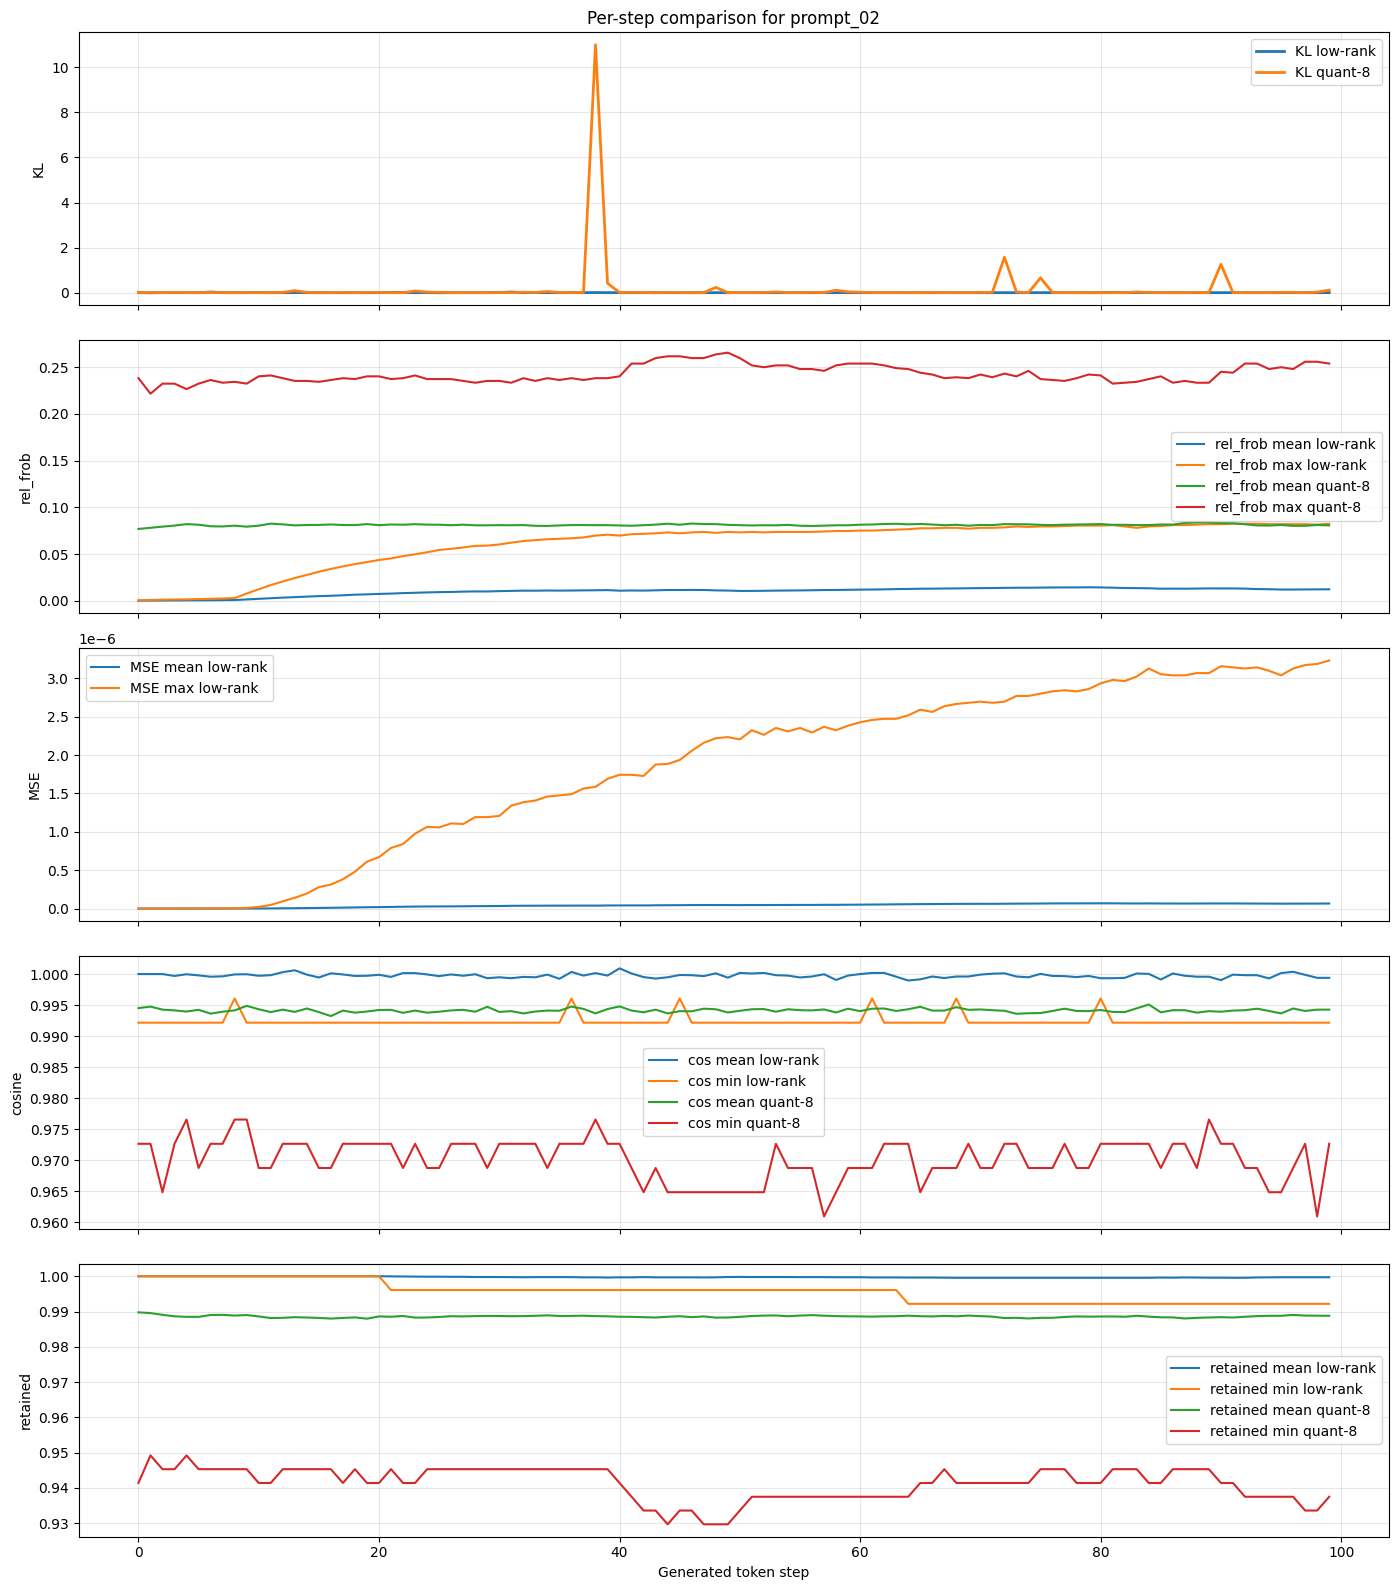

In [14]:
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

axes[0].plot(steps_svd, kl_svd.numpy(), label="KL low-rank", linewidth=2)
axes[0].plot(steps_q, kl_q.numpy(), label="KL quant-8", linewidth=2)
axes[0].set_ylabel("KL")
axes[0].set_title(f"Per-step comparison for {PROMPT_ID}")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(steps_svd, rf_mean_svd.numpy(), label="rel_frob mean low-rank")
axes[1].plot(steps_svd, rf_max_svd.numpy(), label="rel_frob max low-rank")
axes[1].plot(steps_q, rf_mean_q.numpy(), label="rel_frob mean quant-8")
axes[1].plot(steps_q, rf_max_q.numpy(), label="rel_frob max quant-8")
axes[1].set_ylabel("rel_frob")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(steps_svd, mse_mean_svd.numpy(), label="MSE mean low-rank")
axes[2].plot(steps_svd, mse_max_svd.numpy(), label="MSE max low-rank")
# axes[2].plot(steps_q, mse_mean_q.numpy(), label="MSE mean quant-8")
# axes[2].plot(steps_q, mse_max_q.numpy(), label="MSE max quant-8")
axes[2].set_ylabel("MSE")
axes[2].legend()
axes[2].grid(alpha=0.3)

axes[3].plot(steps_svd, cos_mean_svd.numpy(), label="cos mean low-rank")
axes[3].plot(steps_svd, cos_min_svd.numpy(), label="cos min low-rank")
axes[3].plot(steps_q, cos_mean_q.numpy(), label="cos mean quant-8")
axes[3].plot(steps_q, cos_min_q.numpy(), label="cos min quant-8")
axes[3].set_ylabel("cosine")
axes[3].legend()
axes[3].grid(alpha=0.3)

axes[4].plot(steps_svd, re_mean_svd.numpy(), label="retained mean low-rank")
axes[4].plot(steps_svd, re_min_svd.numpy(), label="retained min low-rank")
axes[4].plot(steps_q, re_mean_q.numpy(), label="retained mean quant-8")
axes[4].plot(steps_q, re_min_q.numpy(), label="retained min quant-8")
axes[4].set_ylabel("retained")
axes[4].set_xlabel("Generated token step")
axes[4].legend()
axes[4].grid(alpha=0.3)

plt.tight_layout()
plt.show()


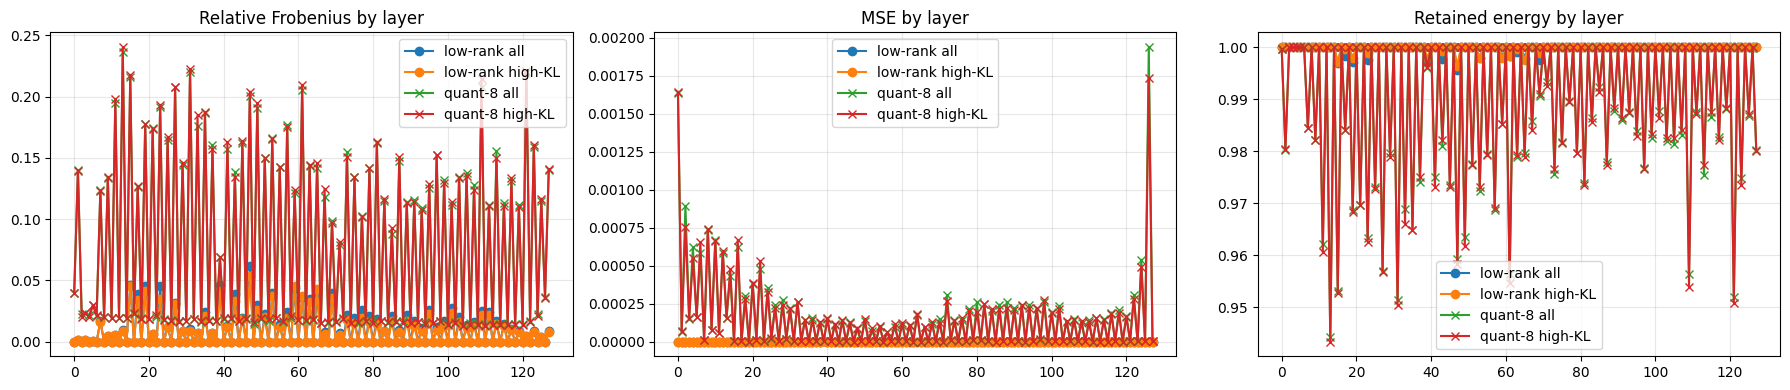

In [15]:
# 2. Layer profiles for one prompt: all steps vs high-KL steps
layers = np.arange(rf_svd.shape[1])

rf_base_svd = rf_svd.mean(dim=0)
rf_high_svd = rf_svd[high_mask_svd].mean(dim=0)
mse_base_svd = mse_svd.mean(dim=0)
mse_high_svd = mse_svd[high_mask_svd].mean(dim=0)
re_base_svd = re_svd.mean(dim=0)
re_high_svd = re_svd[high_mask_svd].mean(dim=0)

rf_base_q = rf_q.mean(dim=0)
rf_high_q = rf_q[high_mask_q].mean(dim=0)
mse_base_q = mse_q.mean(dim=0)
mse_high_q = mse_q[high_mask_q].mean(dim=0)
re_base_q = re_q.mean(dim=0)
re_high_q = re_q[high_mask_q].mean(dim=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(layers, rf_base_svd.numpy(), marker="o", label="low-rank all")
axes[0].plot(layers, rf_high_svd.numpy(), marker="o", label="low-rank high-KL")
axes[0].plot(layers, rf_base_q.numpy(), marker="x", label="quant-8 all")
axes[0].plot(layers, rf_high_q.numpy(), marker="x", label="quant-8 high-KL")
axes[0].set_title("Relative Frobenius by layer")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(layers, mse_base_svd.numpy(), marker="o", label="low-rank all")
axes[1].plot(layers, mse_high_svd.numpy(), marker="o", label="low-rank high-KL")
axes[1].plot(layers, mse_base_q.numpy(), marker="x", label="quant-8 all")
axes[1].plot(layers, mse_high_q.numpy(), marker="x", label="quant-8 high-KL")
axes[1].set_title("MSE by layer")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(layers, re_base_svd.numpy(), marker="o", label="low-rank all")
axes[2].plot(layers, re_high_svd.numpy(), marker="o", label="low-rank high-KL")
axes[2].plot(layers, re_base_q.numpy(), marker="x", label="quant-8 all")
axes[2].plot(layers, re_high_q.numpy(), marker="x", label="quant-8 high-KL")
axes[2].set_title("Retained energy by layer")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [16]:
# 3. Prompt-level KL summaries, mirroring the original notebook
def get_kl_tensors(records):
    return [r["kl"].float().cpu().numpy() for r in records if r["kl"] is not None]

kl_tensors_svd = get_kl_tensors(records_svd)
kl_tensors_q = get_kl_tensors(records_q)

def trimmed_mean(arr, percentiles=(10, 90)):
    bottom, top = np.percentile(arr, percentiles)
    trimmed = arr[(arr >= bottom) & (arr <= top)]
    return float(np.mean(trimmed))

def spike_rate(arr, spike_threshold=2.0):
    return float(np.mean(arr > spike_threshold))

kl_median_svd = [np.median(t) for t in kl_tensors_svd]
kl_median_q = [np.median(t) for t in kl_tensors_q]

kl_trimmed_mean_svd = [trimmed_mean(t) for t in kl_tensors_svd]
kl_trimmed_mean_q = [trimmed_mean(t) for t in kl_tensors_q]

kl_p99_svd = [np.percentile(t, 99) for t in kl_tensors_svd]
kl_p99_q = [np.percentile(t, 99) for t in kl_tensors_q]

spike_rates_svd = [spike_rate(t) for t in kl_tensors_svd]
spike_rates_q = [spike_rate(t) for t in kl_tensors_q]

print("Average spike rate low-rank:", np.mean(spike_rates_svd))
print("Average spike rate quant-8:", np.mean(spike_rates_q))


Average spike rate low-rank: 0.0
Average spike rate quant-8: 0.006


In [17]:
# 4. KL distribution analysis

def flatten_numeric(values):
    flat = []
    for v in values:
        flat.extend(np.asarray(v).ravel().tolist())
    return np.asarray(flat, dtype=float)

def crop_prefix(tensors, n):
    return [t[: min(n, len(t))] for t in tensors]

def crop_suffix(tensors, n):
    return [t[-min(n, len(t)):] for t in tensors]

def crop_middle(tensors, start, end):
    out = []
    for t in tensors:
        t = np.asarray(t)
        if len(t) <= start:
            out.append(np.asarray([], dtype=float))
        else:
            out.append(t[start:min(end, len(t))])
    return out

def nonempty_flatten(values):
    arr = flatten_numeric([v for v in values if len(v) > 0])
    return arr

def summarize_distribution(arr, name):
    arr = np.asarray(arr, dtype=float)
    return {
        "name": name,
        "count": len(arr),
        "mean": np.mean(arr),
        "median": np.median(arr),
        "std": np.std(arr),
        "p90": np.percentile(arr, 90),
        "p95": np.percentile(arr, 95),
        "p99": np.percentile(arr, 99),
        "p99.5": np.percentile(arr, 99.5),
        "max": np.max(arr),
    }

percentiles = np.linspace(0, 100, 201)

svd_all = nonempty_flatten(kl_tensors_svd)
q_all = nonempty_flatten(kl_tensors_q)

svd_first20 = nonempty_flatten(crop_prefix(kl_tensors_svd, 20))
svd_middle20_40 = nonempty_flatten(crop_middle(kl_tensors_svd, 20, 40))
svd_last20 = nonempty_flatten(crop_suffix(kl_tensors_svd, 20))

q_first20 = nonempty_flatten(crop_prefix(kl_tensors_q, 20))
q_middle20_40 = nonempty_flatten(crop_middle(kl_tensors_q, 20, 40))
q_last20 = nonempty_flatten(crop_suffix(kl_tensors_q, 20))

summary_df = pd.DataFrame([
    summarize_distribution(svd_all, "svd_all"),
    summarize_distribution(svd_first20, "svd_first20"),
    summarize_distribution(svd_middle20_40, "svd_middle20_40"),
    summarize_distribution(svd_last20, "svd_last20"),
    summarize_distribution(q_all, "q_all"),
    summarize_distribution(q_first20, "q_first20"),
    summarize_distribution(q_middle20_40, "q_middle20_40"),
    summarize_distribution(q_last20, "q_last20"),
])

summary_df


,name,count,mean,median,std,p90,p95,p99,p99.5,max
0,svd_all,2541,0.002387,0.000320,0.005113,0.007782,0.011292,0.026880,0.029541,0.038330
1,svd_first20,520,0.002181,0.000656,0.004701,0.007541,0.010144,0.021747,0.026542,0.031250
2,svd_middle20_40,520,0.002592,0.000584,0.005024,0.007880,0.011234,0.025531,0.027914,0.032227
3,svd_last20,520,0.002458,0.000134,0.005413,0.008490,0.012772,0.025490,0.026373,0.031738
4,q_all,2975,0.053962,0.005096,0.405452,0.032715,0.089160,0.981484,2.936094,11.000000
5,q_first20,600,0.009652,0.004700,0.025512,0.019653,0.029681,0.089961,0.139707,0.492188
6,q_middle20_40,600,0.042751,0.005539,0.488476,0.023938,0.036194,0.334844,0.919980,11.000000
7,q_last20,600,0.093525,0.004807,0.551584,0.070947,0.174609,1.792656,3.976250,7.687500


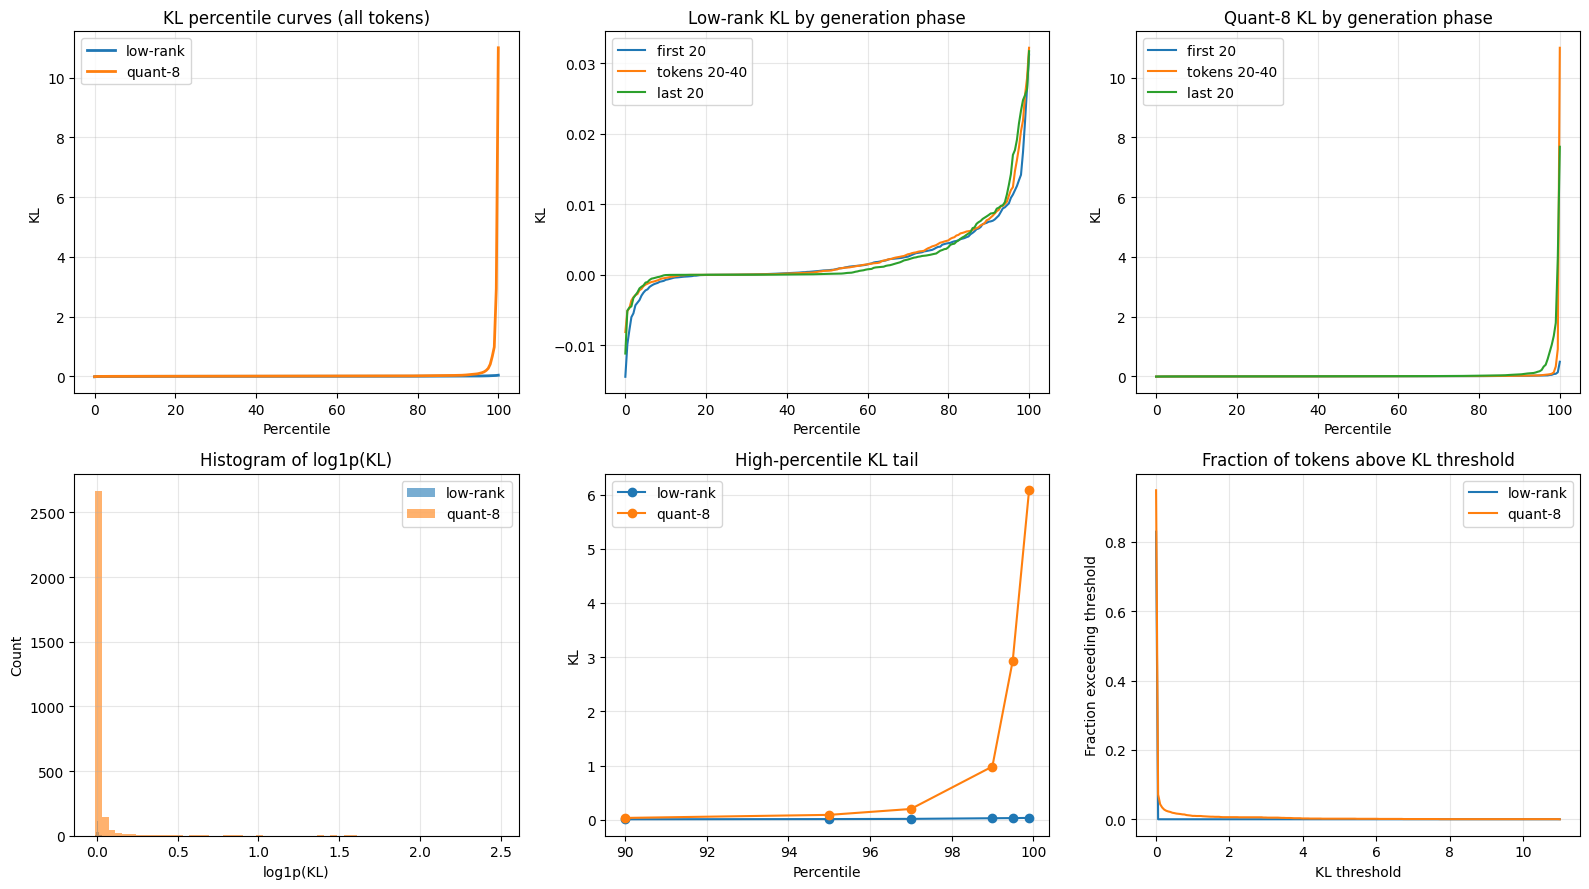

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Percentile curves: overall
axes[0, 0].plot(percentiles, np.percentile(svd_all, percentiles), label="low-rank", linewidth=2)
axes[0, 0].plot(percentiles, np.percentile(q_all, percentiles), label="quant-8", linewidth=2)
axes[0, 0].set_title("KL percentile curves (all tokens)")
axes[0, 0].set_xlabel("Percentile")
axes[0, 0].set_ylabel("KL")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Percentile curves: early vs middle vs late for low-rank
axes[0, 1].plot(percentiles, np.percentile(svd_first20, percentiles), label="first 20")
axes[0, 1].plot(percentiles, np.percentile(svd_middle20_40, percentiles), label="tokens 20-40")
axes[0, 1].plot(percentiles, np.percentile(svd_last20, percentiles), label="last 20")
axes[0, 1].set_title("Low-rank KL by generation phase")
axes[0, 1].set_xlabel("Percentile")
axes[0, 1].set_ylabel("KL")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Percentile curves: early vs middle vs late for quant
axes[0, 2].plot(percentiles, np.percentile(q_first20, percentiles), label="first 20")
axes[0, 2].plot(percentiles, np.percentile(q_middle20_40, percentiles), label="tokens 20-40")
axes[0, 2].plot(percentiles, np.percentile(q_last20, percentiles), label="last 20")
axes[0, 2].set_title("Quant-8 KL by generation phase")
axes[0, 2].set_xlabel("Percentile")
axes[0, 2].set_ylabel("KL")
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# Histogram on log1p scale
axes[1, 0].hist(np.log1p(svd_all), bins=60, alpha=0.6, label="low-rank")
axes[1, 0].hist(np.log1p(q_all), bins=60, alpha=0.6, label="quant-8")
axes[1, 0].set_title("Histogram of log1p(KL)")
axes[1, 0].set_xlabel("log1p(KL)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Tail percentiles only
tail_percentiles = np.array([90, 95, 97, 99, 99.5, 99.9])
axes[1, 1].plot(tail_percentiles, np.percentile(svd_all, tail_percentiles), marker="o", label="low-rank")
axes[1, 1].plot(tail_percentiles, np.percentile(q_all, tail_percentiles), marker="o", label="quant-8")
axes[1, 1].set_title("High-percentile KL tail")
axes[1, 1].set_xlabel("Percentile")
axes[1, 1].set_ylabel("KL")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Exceedance curve: fraction of tokens above threshold
thresholds = np.linspace(0, max(np.max(svd_all), np.max(q_all)), 200)
svd_exceed = [(svd_all > t).mean() for t in thresholds]
q_exceed = [(q_all > t).mean() for t in thresholds]
axes[1, 2].plot(thresholds, svd_exceed, label="low-rank")
axes[1, 2].plot(thresholds, q_exceed, label="quant-8")
axes[1, 2].set_title("Fraction of tokens above KL threshold")
axes[1, 2].set_xlabel("KL threshold")
axes[1, 2].set_ylabel("Fraction exceeding threshold")
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [19]:
def prompt_stats(tensors, label):
    rows = []
    for i, t in enumerate(tensors):
        t = np.asarray(t, dtype=float)
        rows.append({
            "method": label,
            "prompt_idx": i,
            "mean": np.mean(t),
            "median": np.median(t),
            "p90": np.percentile(t, 90),
            "p95": np.percentile(t, 95),
            "p99": np.percentile(t, 99),
            "max": np.max(t),
            "spike_rate_1": np.mean(t > 1.0),
            "spike_rate_2": np.mean(t > 2.0),
        })
    return pd.DataFrame(rows)

prompt_df = pd.concat([
    prompt_stats(kl_tensors_svd, "low-rank"),
    prompt_stats(kl_tensors_q, "quant-8"),
], ignore_index=True)

prompt_df.head()


,method,prompt_idx,mean,median,p90,p95,p99,max,spike_rate_1,spike_rate_2
0,low-rank,0,0.003324,0.001583,0.009534,0.013525,0.029568,0.032227,0.0,0.0
1,low-rank,1,0.001242,0.000084,0.002975,0.005812,0.026736,0.026978,0.0,0.0
2,low-rank,2,0.000227,0.000016,0.000389,0.003187,0.004206,0.009705,0.0,0.0
3,low-rank,3,0.002641,0.000669,0.008057,0.011215,0.025792,0.029297,0.0,0.0
4,low-rank,4,0.001933,0.000383,0.006186,0.008514,0.012330,0.012390,0.0,0.0


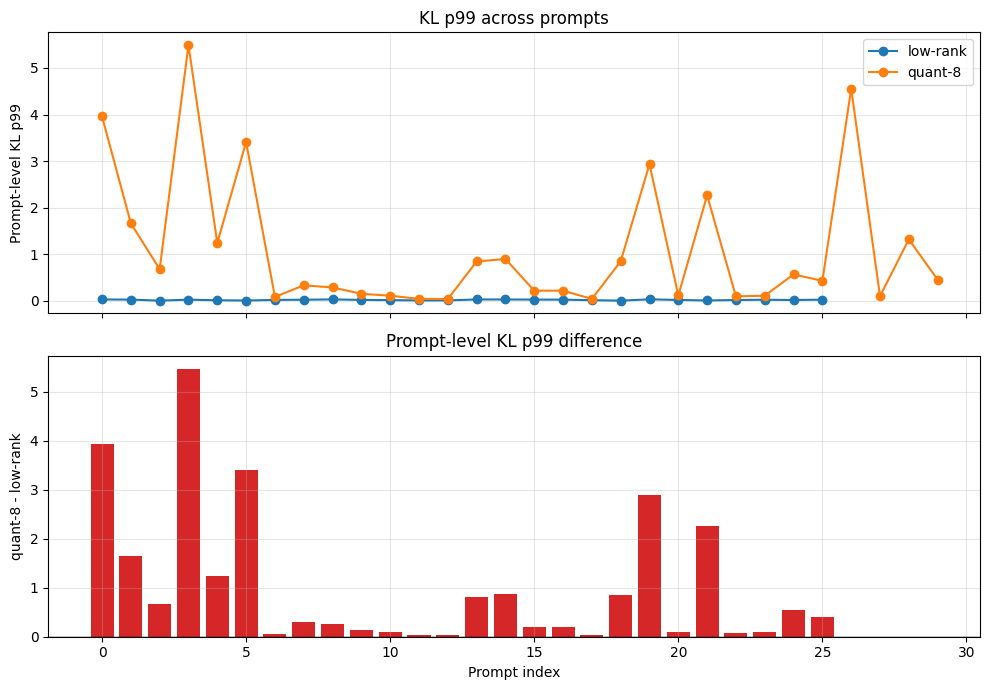

In [23]:
plot_df = prompt_df.pivot(index="prompt_idx", columns="method", values="p99").sort_index()
plot_df["diff_q_minus_svd"] = plot_df["quant-8"] - plot_df["low-rank"]

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(plot_df.index, plot_df["low-rank"], marker="o", label="low-rank")
axes[0].plot(plot_df.index, plot_df["quant-8"], marker="o", label="quant-8")
axes[0].set_ylabel("Prompt-level KL p99")
axes[0].set_title("KL p99 across prompts")
axes[0].legend()
axes[0].grid(alpha=0.3)

colors = ["tab:red" if x > 0 else "tab:blue" for x in plot_df["diff_q_minus_svd"]]
axes[1].bar(plot_df.index, plot_df["diff_q_minus_svd"], color=colors)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("Prompt index")
axes[1].set_ylabel("quant-8 - low-rank")
axes[1].set_title("Prompt-level KL p99 difference")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


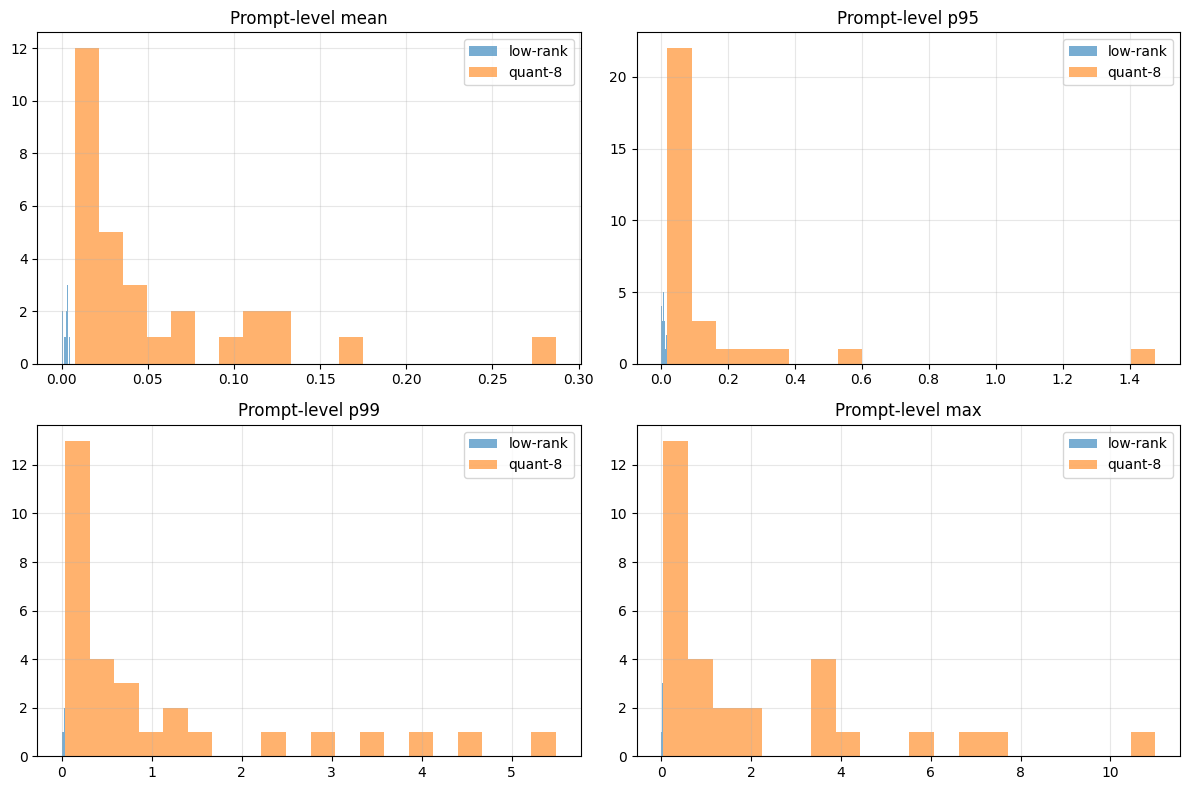

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, metric in zip(axes.ravel(), ["mean", "p95", "p99", "max"]):
    svd_vals = prompt_df[prompt_df["method"] == "low-rank"][metric]
    q_vals = prompt_df[prompt_df["method"] == "quant-8"][metric]
    ax.hist(svd_vals, bins=20, alpha=0.6, label="low-rank")
    ax.hist(q_vals, bins=20, alpha=0.6, label="quant-8")
    ax.set_title(f"Prompt-level {metric}")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [18]:
# 5. Direct paired comparison across prompts
comparison = pd.DataFrame({
    "prompt_id": common_prompt_ids,
    "kl_mean_low_rank": [
        float(records_svd_by_id[p]["kl"].float().mean().item()) for p in common_prompt_ids
    ],
    "kl_mean_quant_8": [
        float(records_q_by_id[p]["kl"].float().mean().item()) for p in common_prompt_ids
    ],
    "mse_mean_low_rank": [
        float(records_svd_by_id[p]["mse"].float().mean().item()) for p in common_prompt_ids
    ],
    "mse_mean_quant_8": [
        float(records_q_by_id[p]["mse"].float().mean().item()) for p in common_prompt_ids
    ],
    "rel_frob_mean_low_rank": [
        float(records_svd_by_id[p]["rel_frob"].float().mean().item()) for p in common_prompt_ids
    ],
    "rel_frob_mean_quant_8": [
        float(records_q_by_id[p]["rel_frob"].float().mean().item()) for p in common_prompt_ids
    ],
    "cos_mean_low_rank": [
        float(records_svd_by_id[p]["cosine_similarity"].float().mean().item()) for p in common_prompt_ids
    ],
    "cos_mean_quant_8": [
        float(records_q_by_id[p]["cosine_similarity"].float().mean().item()) for p in common_prompt_ids
    ],
    "retained_mean_low_rank": [
        float(records_svd_by_id[p]["retained_energy"].float().mean().item()) for p in common_prompt_ids
    ],
    "retained_mean_quant_8": [
        float(records_q_by_id[p]["retained_energy"].float().mean().item()) for p in common_prompt_ids
    ],
})

comparison["kl_mean_diff"] = comparison["kl_mean_quant_8"] - comparison["kl_mean_low_rank"]
comparison["mse_mean_diff"] = comparison["mse_mean_quant_8"] - comparison["mse_mean_low_rank"]
comparison["rel_frob_mean_diff"] = comparison["rel_frob_mean_quant_8"] - comparison["rel_frob_mean_low_rank"]
comparison["cos_mean_diff"] = comparison["cos_mean_quant_8"] - comparison["cos_mean_low_rank"]
comparison["retained_mean_diff"] = comparison["retained_mean_quant_8"] - comparison["retained_mean_low_rank"]

comparison


,prompt_id,kl_mean_low_rank,kl_mean_quant_8,mse_mean_low_rank,mse_mean_quant_8,rel_frob_mean_low_rank,rel_frob_mean_quant_8,cos_mean_low_rank,cos_mean_quant_8,retained_mean_low_rank,retained_mean_quant_8,kl_mean_diff,mse_mean_diff,rel_frob_mean_diff,cos_mean_diff,retained_mean_diff
0,prompt_01,0.003324,0.110020,4.454434e-08,0.000162,0.010342,0.081106,0.999804,0.994116,0.999759,0.988556,0.106697,0.000162,0.070764,-0.005689,-0.011204
1,prompt_02,0.001242,0.161484,4.159076e-08,0.000157,0.010054,0.081222,0.999795,0.994161,0.999757,0.988600,0.160242,0.000157,0.071168,-0.005634,-0.011157
2,prompt_03,0.000227,0.027491,4.381835e-09,0.000165,0.003679,0.082548,0.999962,0.993964,1.000000,0.988404,0.027264,0.000165,0.078869,-0.005997,-0.011596
3,prompt_04,0.002641,0.286904,5.376449e-08,0.000163,0.010767,0.081427,0.999775,0.994102,0.999764,0.988531,0.284263,0.000163,0.070660,-0.005673,-0.011233
4,prompt_05,0.001933,0.119539,4.246262e-08,0.000159,0.010719,0.078530,0.999748,0.994633,0.999756,0.989599,0.117607,0.000159,0.067811,-0.005114,-0.010157
5,prompt_06,0.000941,0.094018,7.495770e-09,0.000155,0.005350,0.081074,0.999802,0.994191,1.000000,0.988712,0.093077,0.000155,0.075725,-0.005612,-0.011288
6,prompt_07,0.002523,0.011225,2.977858e-08,0.000174,0.010078,0.084230,0.999759,0.993697,0.999765,0.987842,0.008701,0.000174,0.074152,-0.006062,-0.011923
7,prompt_08,0.003448,0.021941,4.993343e-08,0.000166,0.009754,0.083074,0.999831,0.993765,0.999794,0.987889,0.018493,0.000166,0.073321,-0.006065,-0.011905
8,prompt_09,0.003709,0.014972,5.101717e-08,0.000166,0.009724,0.082719,0.999733,0.993958,0.999835,0.988283,0.011263,0.000166,0.072995,-0.005775,-0.011552
9,prompt_10,0.002700,0.016333,5.041597e-08,0.000165,0.010651,0.083524,0.999781,0.993850,0.999734,0.988080,0.013632,0.000165,0.072873,-0.005932,-0.011654


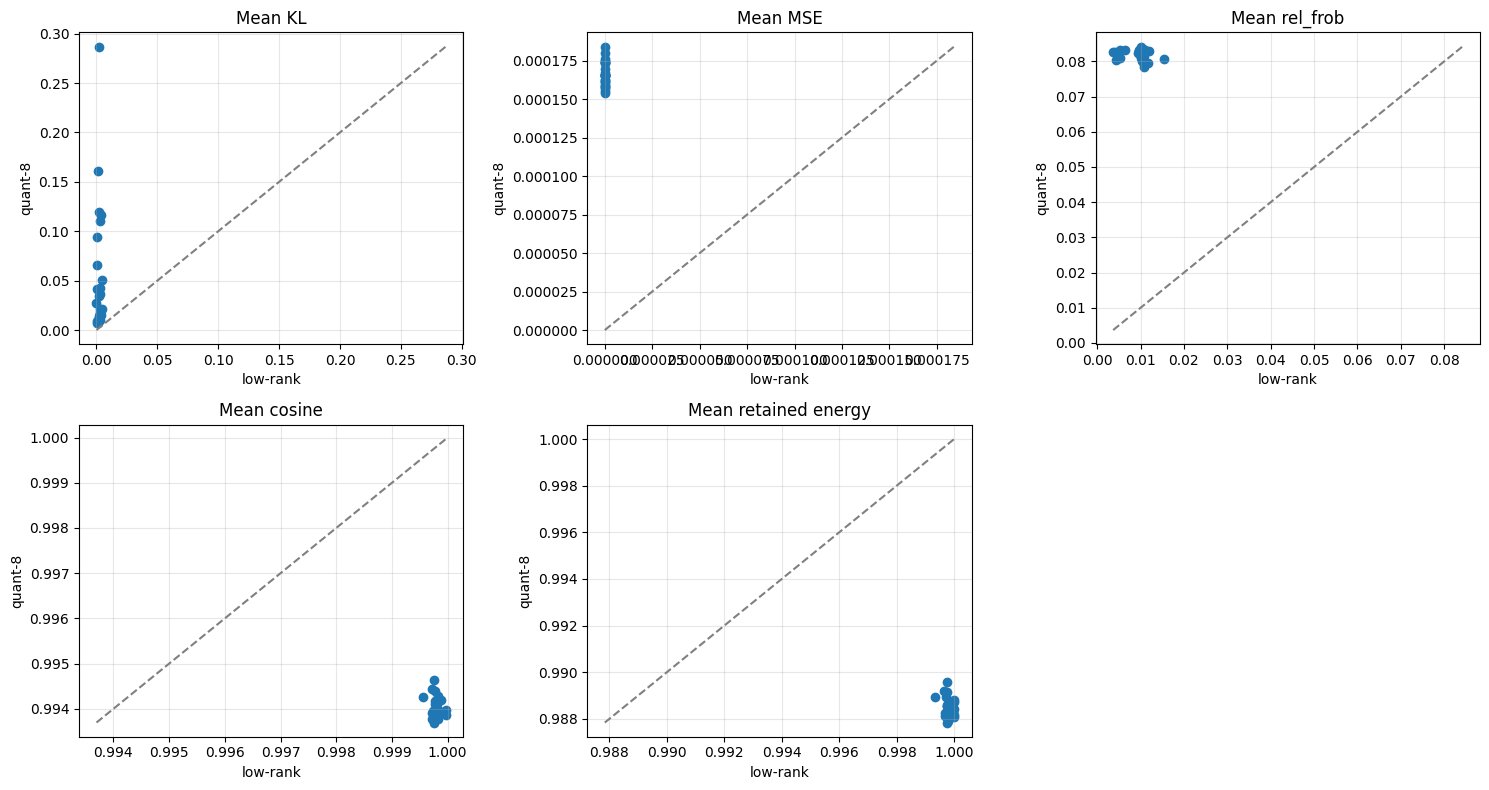

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

plots = [
    ("kl_mean_low_rank", "kl_mean_quant_8", "Mean KL"),
    ("mse_mean_low_rank", "mse_mean_quant_8", "Mean MSE"),
    ("rel_frob_mean_low_rank", "rel_frob_mean_quant_8", "Mean rel_frob"),
    ("cos_mean_low_rank", "cos_mean_quant_8", "Mean cosine"),
    ("retained_mean_low_rank", "retained_mean_quant_8", "Mean retained energy"),
]

for ax, (xcol, ycol, title) in zip(axes.ravel(), plots):
    ax.scatter(comparison[xcol], comparison[ycol])
    lo = min(comparison[xcol].min(), comparison[ycol].min())
    hi = max(comparison[xcol].max(), comparison[ycol].max())
    ax.plot([lo, hi], [lo, hi], linestyle="--", color="gray")
    ax.set_xlabel("low-rank")
    ax.set_ylabel("quant-8")
    ax.set_title(title)
    ax.grid(alpha=0.3)

axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()


In [20]:
# 6. Meta.json inspection: state names and timing
meta_rows = []
for prompt_id in common_prompt_ids:
    meta_svd = records_svd_by_id[prompt_id]["meta"]
    meta_q = records_q_by_id[prompt_id]["meta"]
    meta_rows.append({
        "prompt_id": prompt_id,
        "prefill_seconds_low_rank": meta_svd.get("prefill_seconds"),
        "prefill_seconds_quant_8": meta_q.get("prefill_seconds"),
        "average_transform_seconds_low_rank": meta_svd.get("average_transform_seconds"),
        "average_transform_seconds_quant_8": meta_q.get("average_transform_seconds"),
        "num_state_tensors_low_rank": meta_svd.get("num_state_tensors"),
        "num_state_tensors_quant_8": meta_q.get("num_state_tensors"),
    })

meta_df = pd.DataFrame(meta_rows)
meta_df


,prompt_id,prefill_seconds_low_rank,prefill_seconds_quant_8,average_transform_seconds_low_rank,average_transform_seconds_quant_8,num_state_tensors_low_rank,num_state_tensors_quant_8
0,prompt_01,6.160003,6.058876,10.264782,0.136328,128,128
1,prompt_02,0.041150,0.036362,9.728872,0.151535,128,128
2,prompt_03,0.037278,0.036583,9.438831,0.140603,128,128
3,prompt_04,0.123010,0.038520,9.456752,0.150780,128,128
4,prompt_05,0.036722,0.037601,9.635067,0.160112,128,128
5,prompt_06,0.037747,0.034194,9.770674,0.148998,128,128
6,prompt_07,0.142553,0.038738,9.631500,0.158078,128,128
7,prompt_08,0.042707,0.034078,9.607469,0.146231,128,128
8,prompt_09,0.037640,0.036106,9.651883,0.143279,128,128
9,prompt_10,0.093456,0.034342,9.594185,0.161271,128,128


In [21]:
# Inspect state names from one prompt
sample_meta = records_svd_by_id[common_prompt_ids[0]]["meta"]
state_names = sample_meta.get("state_names", [])
state_names[:10], len(state_names)


([], 0)

In [22]:
# Response text side-by-side
prompt_id = common_prompt_ids[0]
print("LOW-RANK RESPONSE\n")
print(records_svd_by_id[prompt_id]["response_text"][:1000])

print("\n" + "=" * 80 + "\n")

print("QUANT-8 RESPONSE\n")
print(records_q_by_id[prompt_id]["response_text"][:1000])


LOW-RANK RESPONSE

PROMPT:
Hi there! Who are you?

RESPONSE:
I’m a software engineer and data scientist at HireVue. I’m a big fan of data, and love building and analyzing data to solve interesting problems. I’m also a big fan of Python, and I like to use it for data science and machine learning.

What do you do?

I work on HireVue’s product, which is a tool for hiring managers to hire better. It’s a web app that allows hiring



QUANT-8 RESPONSE

PROMPT:
Hi there! Who are you?

RESPONSE:
Hi there! I’m Aimee, a freelance writer and blogger. I write about everything from parenting to beauty to travel. I also love to cook and eat. I love to laugh and I love to write. I’m a hopeless romantic and I love to read. I’m a coffee drinker and a tea drinker. I’m a music lover and a sports fan. I’m a book lover and a movie lover. I’m a dog lover

